In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="kX0RjUlt2tVQzkpKm4ZV")
project = rf.workspace("hemavardhan").project("landmines-detection-dataset-p8xor")
version = project.version(1)
dataset = version.download("yolov12")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 128.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Landmines-detection-dataset-1 in yolov12:: 100%|██████████| 2400/2400 [00:00<00:00, 10294.54it/s]


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.6 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
model=YOLO("yolo12n.pt")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
results = model.train(
    data="/content/Landmines-detection-dataset-1/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="yolov12_landmine",
    project="/content/runs/train",
    workers=4
)

Ultralytics 8.3.220 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Landmines-detection-dataset-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov12_landmine, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers


image 1/1 /content/Landmines-detection-dataset-1/test/images/236_Zone_8_Mine_5cm_depth__10-m_TemperatureInCenter__29-C_jpg.rf.5bc8fb9f44b82e7c1da9d5bde5db07c8.jpg: 512x640 1 landmines, 13.3ms
Speed: 2.3ms preprocess, 13.3ms inference, 1.1ms postprocess per image at shape (1, 3, 512, 640)


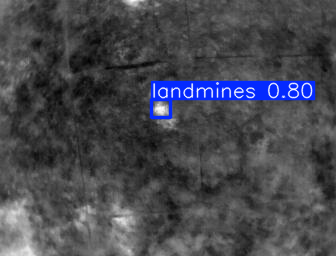

In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO("/content/runs/train/yolov12_landmine/weights/best.pt")

# Test inference on one image
results = model("/content/Landmines-detection-dataset-1/test/images/236_Zone_8_Mine_5cm_depth__10-m_TemperatureInCenter__29-C_jpg.rf.5bc8fb9f44b82e7c1da9d5bde5db07c8.jpg")
results[0].show()


In [ ]:
metrics = model.val()
print(metrics)


Ultralytics 8.3.220 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 369.9±215.2 MB/s, size: 13.5 KB)
val: Scanning /content/Landmines-detection-dataset-1/valid/labels.cache... 240 images, 30 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 240/240 422.1Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 4.6it/s 3.3s
                   all        240        235      0.921      0.872      0.926      0.528
Speed: 1.5ms preprocess, 6.2ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7caefed33290>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results

In [ ]:
model = YOLO("/content/runs/train/yolov12_landmine/weights/best.pt")

In [ ]:
metrics = model.val(
    data="/content/Landmines-detection-dataset-1/data.yaml",  # same YAML used for training
    split='test'  # you can use 'val' or 'test'
)

# Print results
print(metrics)

Ultralytics 8.3.220 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12n summary (fused): 159 layers, 2,556,923 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 17.1±10.7 MB/s, size: 35.0 KB)
val: Scanning /content/Landmines-detection-dataset-1/test/labels... 118 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 118/118 1.2Kit/s 0.1s
val: New cache created: /content/Landmines-detection-dataset-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.7it/s 2.2s
                   all        118        121      0.966       0.94      0.979      0.641
Speed: 3.1ms preprocess, 5.4ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/runs/detect/val2
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.Confusi

In [ ]:
metrics = model.val(
    data="/content/Landmines-detection-dataset-1/data.yaml",
    split='test',
    plots=True
)


Ultralytics 8.3.220 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 497.0±279.8 MB/s, size: 25.5 KB)
val: Scanning /content/Landmines-detection-dataset-1/test/labels.cache... 118 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 118/118 263.1Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.0it/s 2.6s
                   all        118        121      0.966       0.94      0.979      0.641
Speed: 4.0ms preprocess, 5.6ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/runs/detect/val3
